In [1]:
import os
import time
import torch
import skimage
import sklearn.metrics
import torchvision

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from tqdm import tqdm
# from torchvision.ops import sigmoid_focal_loss

import sys
sys.path.append('../')
from microdet import mnds

In [2]:
SCALE_FACTOR = 1.0
PATCH_SIZE = 256
STRIDE = 8
FEATURE_SIZE = 384
TOKENS_PER_PATCH = PATCH_SIZE // STRIDE
STEP = 16
EPOCHS = 20
THRESHOLD = 0.5

LOSS_FN = 'combined'
LR = 1e-5
BATCH_SIZE = 32
FINETUNE = True
WEIGHT_DECAY = 1e-6


CURRENT_PATH = os.getcwd()
DIRECTORY = CURRENT_PATH + '/dataset_v2'
OUTPUT_DIR = "/model_output/output/"

In [3]:
files = os.listdir(DIRECTORY)
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()
# annot_files = annot_files[0:10] # using all 18 images


i = 0
training_files = annot_files.copy()
validation_files = [annot_files[i]]
del training_files[i]
print(len(training_files))

17


In [4]:
training_set = mnds.MicronucleiDataset(
    filelist=training_files, 
    directory=DIRECTORY, 
    mode="random",
    edges=True,
    transform=mnds.detection_transforms,
    scale_factor=SCALE_FACTOR,
    patch_size=PATCH_SIZE
)

100%|██████████| 17/17 [01:03<00:00,  3.71s/it]


In [5]:
crop, mask = next(iter(training_set))
print(crop.shape, mask.shape)

# Check if interpolation messed up the binary mask values

In [8]:
np.unique(mask)

array([0., 1.], dtype=float32)

In [11]:
np.unique(crop)

array([0.0000000e+00, 3.7252903e-08, 7.2829425e-07, ..., 9.9971837e-01,
       9.9985379e-01, 1.0000000e+00], dtype=float32)

# Explore Sigma Values Effect

In [3]:
sigma_files = os.listdir('/scr/yren/sigma_experiment')
sigma_files

['sigma_experiment_25.txt',
 'sigma_experiment_20.txt',
 'sigma_experiment_10.txt',
 'sigma_experiment_5.txt',
 'sigma_experiment_15.txt']

In [4]:
df = pd.DataFrame(columns=['experiment', 'precision', 'recall'])
df

,experiment,precision,recall


In [5]:
with open('/scr/yren/sigma_experiment/sigma_experiment_5.txt') as file:
    content = file.read()
    print(content)

20X_c0-DAPI_A1_Tile-10,0.5983,0.8434
20X_c0-DAPI_A1_Tile-110,0.4533,0.7727
20X_c0-DAPI_A1_Tile-130,0.7914,0.7914
20X_c0-DAPI_A1_Tile-150,0.6176,0.8077
20X_c0-DAPI_A1_Tile-170,0.7448,0.7883
20X_c0-DAPI_A1_Tile-190,0.7692,0.8000
20X_c0-DAPI_A1_Tile-30,0.6735,0.6875
20X_c0-DAPI_A1_Tile-50,0.8095,0.7301
20X_c0-DAPI_A1_Tile-70,0.8596,0.7538
20X_c0-DAPI_A1_Tile-90,0.7739,0.8165
C2-20X_c0-DAPI-GFP_A1_Tile-17,0.7531,0.7722
C2-20X_c0-DAPI-GFP_A1_Tile-5,0.8690,0.8795
C2-20X_c0-DAPI-GFP_A2_Tile-5,0.7895,0.9036
C2-20X_c0-DAPI-GFP_A3_Tile-6,0.8415,0.7188
C2-20X_c0-DAPI-GFP_B1_Tile-8,0.5859,0.9062
C2-20X_c0-DAPI-GFP_B2_Tile-20,0.8511,0.9195
C2-20X_c0-DAPI-GFP_B3_Tile-10,0.8455,0.7591
C2-20X_c0-DAPI-GFP_B3_Tile-16,0.8000,0.8400



In [32]:
df = pd.DataFrame(columns=['experiment', 'metric', 'value'])
for sigma_file in sigma_files:
    with open(f'/scr/yren/sigma_experiment/{sigma_file}', 'r') as file:
        experiment = sigma_file.split('.')[0]
        precisions = []
        recalls = []
        
        for line in file:
            precision = float(line.split(',')[1])
            recall = float(line.split(',')[2])
            
            precisions.append(precision)
            recalls.append(recall)
        
        # only average on screen
        d = {'experiment':[experiment, experiment], 'metric':['precision', 'recall'], 'value':[np.mean(precisions[10:18]), np.mean(recalls[10:18])]}
        df_sub = pd.DataFrame(data=d)
        df = pd.concat([df, df_sub], ignore_index=True)
        d = {}

/tmp/ipykernel_1992650/1054131686.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df_sub], ignore_index=True)


In [33]:
df['sigma'] = df['experiment'].str.extract(r'(\d+)').astype(int)
df

,experiment,metric,value,sigma
0,sigma_experiment_25,precision,0.815562,25
1,sigma_experiment_25,recall,0.825862,25
2,sigma_experiment_20,precision,0.782750,20
3,sigma_experiment_20,recall,0.874225,20
4,sigma_experiment_10,precision,0.773837,10
5,sigma_experiment_10,recall,0.812013,10
6,sigma_experiment_5,precision,0.791950,5
7,sigma_experiment_5,recall,0.837363,5
8,sigma_experiment_15,precision,0.816213,15
9,sigma_experiment_15,recall,0.825875,15


In [34]:
d = {'experiment':['best_without_gaussian', 'best_without_gaussian'], 'metric':['precision', 'recall'], 'value':[0.804025, 0.851225], 'sigma':[0,0]}
df_sub = pd.DataFrame(data=d)
df = pd.concat([df, df_sub], ignore_index=True)
df

,experiment,metric,value,sigma
0,sigma_experiment_25,precision,0.815562,25
1,sigma_experiment_25,recall,0.825862,25
2,sigma_experiment_20,precision,0.782750,20
3,sigma_experiment_20,recall,0.874225,20
4,sigma_experiment_10,precision,0.773837,10
5,sigma_experiment_10,recall,0.812013,10
6,sigma_experiment_5,precision,0.791950,5
7,sigma_experiment_5,recall,0.837363,5
8,sigma_experiment_15,precision,0.816213,15
9,sigma_experiment_15,recall,0.825875,15


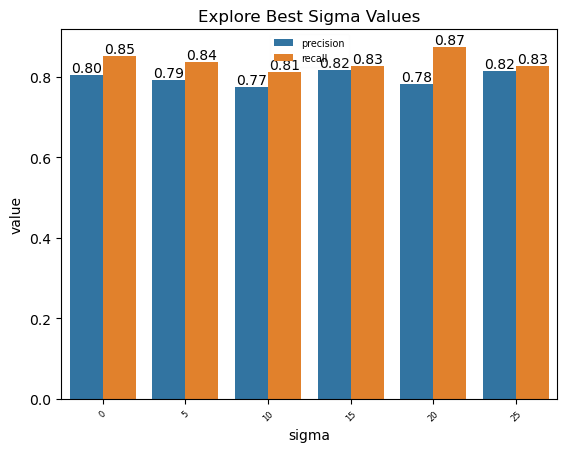

In [35]:
import seaborn as sns

sns.barplot(
    data=df,
    x='sigma',
    y='value',
    hue = 'metric'
)
plt.title('Explore Best Sigma Values')
plt.xticks(fontsize=6)
plt.tick_params(axis='x', rotation=45)
plt.legend(fancybox=True, framealpha=0.05, fontsize='x-small')

# Add value labels on top of each bar
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0: # avoid plotting value for legend
        plt.text(
            p.get_x() + p.get_width() / 2.,  # X position of the text
            height,  # Y position of the text (height of the bar)
            f'{height:.2f}',  # Text to display
            ha='center',  # Horizontal alignment
            va='bottom'  # Vertical alignment
        )
plt.show()

# Explore postprocessing - Dilation

In [36]:
import numpy as np
import torch
import skimage
import matplotlib.pyplot as plt

In [36]:
pixel = np.array([[0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0],
                  [0, 0, 1, 0, 0],
                  [0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0]], dtype=np.uint8)

pixel_dilated_1 = skimage.morphology.dilation(pixel)
pixel_dilated_1

array([[0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 1, 1, 1, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0]], dtype=uint8)

In [37]:
pixel_dilated_2 = skimage.morphology.dilation(pixel, footprint=skimage.morphology.disk(2))
pixel_dilated_2

array([[0, 0, 1, 0, 0],
       [0, 1, 1, 1, 0],
       [1, 1, 1, 1, 1],
       [0, 1, 1, 1, 0],
       [0, 0, 1, 0, 0]], dtype=uint8)

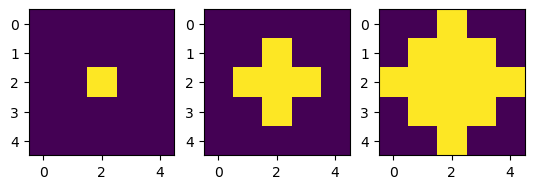

In [38]:
fig, ax = plt.subplots(1,3)
ax[0].imshow(pixel)
ax[1].imshow(pixel_dilated_1)
ax[2].imshow(pixel_dilated_2)

In [37]:
batch_size = 32
patch_size = 256
p = torch.zeros((32,2,256,256))
p[:,0,50,50] = 1
dilated_micron = np.zeros_like(p)
print(dilated_micron.shape)
for i in range(0, dilated_micron.shape[0]):
    dilated_micron[i,0,:,:] = skimage.morphology.dilation(p[i,0,:,:], footprint=skimage.morphology.disk(3))
print(dilated_micron.shape)

p = p.cpu().numpy()
p[:,0,:,:] = dilated_micron[:,0,:,:]

(32, 2, 256, 256)
(32, 2, 256, 256)


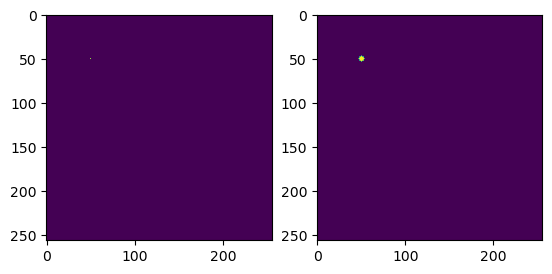

In [30]:
fig, ax = plt.subplots(1,2)
ax[0].imshow(p[5,0,:,:])
ax[1].imshow(dilated_micron[5,0,:,:])

In [38]:
dilation_files = os.listdir('/scr/yren/postprocess')
df = pd.DataFrame(columns=['experiment', 'metric', 'value'])
for dilation_file in dilation_files:
    with open(f'/scr/yren/postprocess/{dilation_file}', 'r') as file:
        experiment = dilation_file.split('.')[0]
        precisions = []
        recalls = []
        
        for line in file:
            precision = float(line.split(',')[1])
            recall = float(line.split(',')[2])
            
            precisions.append(precision)
            recalls.append(recall)
        
        # only average on screen
        d = {'experiment':[experiment, experiment], 'metric':['precision', 'recall'], 'value':[np.mean(precisions[10:18]), np.mean(recalls[10:18])]}
        df_sub = pd.DataFrame(data=d)
        df = pd.concat([df, df_sub], ignore_index=True)
        d = {}

/tmp/ipykernel_1992650/2709935358.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df_sub], ignore_index=True)


In [40]:
df['dilation'] = df['experiment'].str.extract(r'(\d+)').astype(int)
df

,experiment,metric,value,dilation
0,dilation_2,precision,0.831300,2
1,dilation_2,recall,0.859325,2
2,dilation_3,precision,0.820887,3
3,dilation_3,recall,0.868413,3
4,dilation_1,precision,0.811338,1
5,dilation_1,recall,0.846262,1


In [45]:
d = {'experiment':['dilation_0', 'dilation_0'], 'metric':['precision', 'recall'], 'value':[0.78, 0.87], 'dilation':[0,0]}
df_sub = pd.DataFrame(data=d)
df = pd.concat((df, df_sub), ignore_index=True)
df

,experiment,metric,value,dilation
0,dilation_2,precision,0.831300,2
1,dilation_2,recall,0.859325,2
2,dilation_3,precision,0.820887,3
3,dilation_3,recall,0.868413,3
4,dilation_1,precision,0.811338,1
5,dilation_1,recall,0.846262,1
6,dilation_0,precision,0.780000,0
7,dilation_0,recall,0.870000,0


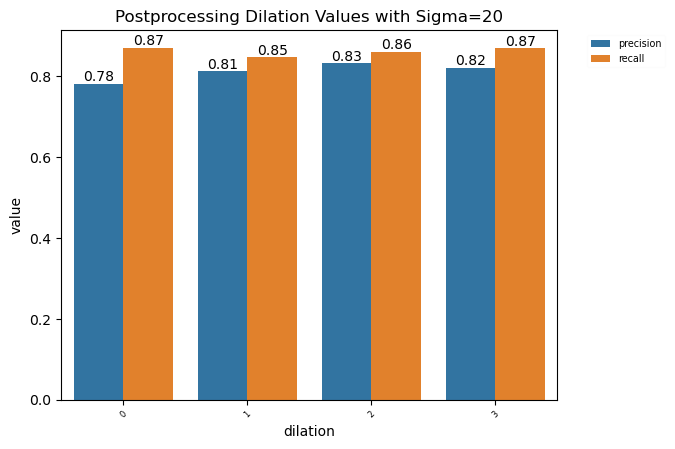

In [48]:
import seaborn as sns

sns.barplot(
    data=df,
    x='dilation',
    y='value',
    hue = 'metric'
)
plt.title('Postprocessing Dilation Values with Sigma=20')
plt.xticks(fontsize=6)
plt.tick_params(axis='x', rotation=45)
plt.legend(fancybox=True, framealpha=0.05, fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.legend(fancybox=True, framealpha=0.05, fontsize='x-small')

# Add value labels on top of each bar
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0: # avoid plotting value for legend
        plt.text(
            p.get_x() + p.get_width() / 2.,  # X position of the text
            height,  # Y position of the text (height of the bar)
            f'{height:.2f}',  # Text to display
            ha='center',  # Horizontal alignment
            va='bottom'  # Vertical alignment
        )
plt.show()